\# This notebook was originally developed and executed in \*\*Google Colab\*\* due to computational constraints encountered in Deepnote\.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    average_precision_score,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv(
    "dataset_merged.csv",
    low_memory=False,
    dtype={"ZIP CODE": "string"}
)

print(df.shape)
df.head()

(1599858, 42)


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,...,wind_speed_10m (km/h),traffic_volume,start_count,end_count,active_construction,construction_change,alteration,demolition,new_building,other
0,2025-12-31,1900-01-01 20:45:00,queens,<NA>,40.716133,-73.818500,"(40.716133, -73.8185)",0.0,0.0,0,...,10.5,109.333672,4.0,12.0,339.0,-8.0,2.0,0.0,0.0,2.0
1,2025-12-31,1900-01-01 11:33:00,brooklyn,11213.0,40.668617,-73.945045,"(40.668617, -73.945045)",0.0,0.0,0,...,16.2,115.431124,1.0,10.0,547.0,-9.0,1.0,0.0,0.0,0.0
2,2025-12-31,1900-01-01 17:15:00,queens,11418.0,40.696865,-73.837166,"(40.696865, -73.837166)",0.0,0.0,0,...,9.4,156.304348,4.0,12.0,339.0,-8.0,2.0,0.0,0.0,2.0
3,2025-12-31,1900-01-01 10:00:00,staten island,10306.0,40.574257,-74.106430,"(40.574257, -74.10643)",0.0,0.0,0,...,13.6,154.798295,0.0,2.0,111.0,-2.0,NaN,NaN,NaN,NaN
4,2025-12-31,1900-01-01 13:50:00,queens,11355.0,40.756800,-73.817070,"(40.7568, -73.81707)",0.0,0.0,0,...,16.3,130.101124,4.0,12.0,339.0,-8.0,2.0,0.0,0.0,2.0


In [3]:
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype('float32')

for col in df.select_dtypes(include=['int64']).columns:
    df[col] = df[col].astype('int32')

print("Memory optimized")

Memory optimized


In [4]:
# Ensure datetime
df["date"] = pd.to_datetime(df["date"])

# ── TIME FEATURES ─────────────────────────
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

df["rush_hour"] = df["hour"].isin([7,8,9,16,17,18]).astype(int)
df["night"] = df["hour"].isin([0,1,2,3,4,23]).astype(int)


# ── WEATHER FEATURES ─────────────────────
df["rain_flag"] = (df["rain (mm)"] > 0).astype(int)
df["snow_flag"] = (df["snowfall (cm)"] > 0).astype(int)
df["high_wind"] = (df["wind_speed_10m (km/h)"] > 30).astype(int)

weather_cols = [
    "rain (mm)",
    "snowfall (cm)",
    "wind_speed_10m (km/h)",
    "cloud_cover (%)"
]

for col in weather_cols:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

df["weather_risk"] = df[weather_cols].mean(axis=1)



# ── CONSTRUCTION INTENSITY ─────────────
df["construction_intensity"] = (
    df["active_construction"] +
    df["construction_change"]
)

In [5]:
# Create severity column
df['SEVERITY'] = ((df['NUMBER OF PERSONS KILLED'] > 0) |
                  (df['NUMBER OF PERSONS INJURED'] >= 1)).astype(int)

# Check distribution
print("Severity Distribution:")
print(df['SEVERITY'].value_counts())
print("\nSeverity Distribution (%):")
print(df['SEVERITY'].value_counts(normalize=True) * 100)

Severity Distribution:
SEVERITY
0    1181984
1     417874
Name: count, dtype: int64

Severity Distribution (%):
SEVERITY
0    73.880557
1    26.119443
Name: proportion, dtype: float64


In [6]:
cols_to_drop = [
    'NUMBER OF PERSONS INJURED',
    'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED',
    'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED',
    'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST INJURED',
    'NUMBER OF MOTORIST KILLED',
    'CRASH DATE', 'CRASH TIME', 'date', 'LOCATION'
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')


In [7]:
print(f" Remaining columns: {df.shape[1]}")
print(df.columns.tolist())

 Remaining columns: 39
['BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3', 'day_of_week', 'year', 'MONTH', 'hour', 'season', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'rain (mm)', 'snowfall (cm)', 'cloud_cover (%)', 'wind_speed_10m (km/h)', 'traffic_volume', 'start_count', 'end_count', 'active_construction', 'construction_change', 'alteration', 'demolition', 'new_building', 'other', 'is_weekend', 'rush_hour', 'night', 'rain_flag', 'snow_flag', 'high_wind', 'weather_risk', 'construction_intensity', 'SEVERITY']


In [8]:
df.drop(columns=['ZIP CODE',  'CONTRIBUTING FACTOR VEHICLE 1',
    'CONTRIBUTING FACTOR VEHICLE 2',
    'CONTRIBUTING FACTOR VEHICLE 3',
    'VEHICLE TYPE CODE 1',
    'VEHICLE TYPE CODE 2',
    'VEHICLE TYPE CODE 3'], inplace=True, errors='ignore')

In [9]:

#Checking and handling any missing values in the dataset.

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing,
                           'Missing %': missing_pct})

# Only show columns with missing values
print(missing_df[missing_df['Missing Count'] > 0])

              Missing Count  Missing %
LATITUDE              37793   2.362272
LONGITUDE             37793   2.362272
alteration           182687  11.418951
demolition           182687  11.418951
new_building         182687  11.418951
other                182687  11.418951


In [10]:
# Drop rows with missing LATITUDE/LONGITUDE
df.dropna(subset=['LATITUDE', 'LONGITUDE'], inplace=True)

# Fill construction columns with 0
construction_cols = ['alteration', 'demolition', 'new_building', 'other']
df[construction_cols] = df[construction_cols].fillna(0)

# Verify no missing values remain
print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Dataset shape after handling missing values: {df.shape}")

Missing values remaining: 0
Dataset shape after handling missing values: (1562065, 32)


In [11]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [12]:
X = df.drop(columns=['SEVERITY'])
y = df['SEVERITY']
print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nClass distribution:\n{y.value_counts()}")

Features shape: (1562065, 31)
Target shape:   (1562065,)

Class distribution:
SEVERITY
0    1152790
1     409275
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Train size: (1249652, 31)
Test size:  (312413, 31)

Train class distribution:
SEVERITY
0    922232
1    327420
Name: count, dtype: int64

Test class distribution:
SEVERITY
0    230558
1     81855
Name: count, dtype: int64


In [14]:
# Calculate class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Negative samples:", neg)
print("Positive samples:", pos)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Negative samples: 922232
Positive samples: 327420
scale_pos_weight: 2.82


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete")
print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape:  {X_test_scaled.shape}")

Scaling complete
Train scaled shape: (1249652, 31)
Test scaled shape:  (312413, 31)


In [16]:
from imblearn.over_sampling import SMOTE

sample_size = 200000

idx = np.random.RandomState(42).choice(len(X_train_scaled), size=200000, replace=False)
X_sample = X_train_scaled[idx]
y_sample = y_train.iloc[idx]

smote = SMOTE(sampling_strategy=0.5, k_neighbors=3, random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_sample, y_sample)

print("SMOTE complete")

print(f"Before SMOTE:")
print(f"  Class 0: {sum(y_train == 0):,}")
print(f"  Class 1: {sum(y_train == 1):,}")
print(f"\nAfter SMOTE:")
print(f"Class 0: {sum(y_train_sm == 0):,}")
print(f"Class 1: {sum(y_train_sm == 1):,}")
print(f"\nNew training size: {X_train_sm.shape}")

SMOTE complete
Before SMOTE:
  Class 0: 922,232
  Class 1: 327,420

After SMOTE:
Class 0: 147,689
Class 1: 73,844

New training size: (221533, 31)


In [17]:
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("PR-AUC:", average_precision_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))

In [18]:
# LR + class_weight
lr_cw = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_cw.fit(X_train_scaled, y_train)

# LR + SMOTE
lr_sm = LogisticRegression(max_iter=1000)
lr_sm.fit(X_train_sm, y_train_sm)

evaluate("LR + class_weight", lr_cw, X_test_scaled, y_test)
evaluate("LR + SMOTE", lr_sm, X_test_scaled, y_test)


LR + class_weight
ROC-AUC: 0.6411659452555563
PR-AUC: 0.37925373038087973
              precision    recall  f1-score   support

           0       0.81      0.66      0.73    230558
           1       0.37      0.57      0.45     81855

    accuracy                           0.63    312413
   macro avg       0.59      0.61      0.59    312413
weighted avg       0.70      0.63      0.65    312413


LR + SMOTE
ROC-AUC: 0.6406655061228601
PR-AUC: 0.3793736382889844
              precision    recall  f1-score   support

           0       0.76      0.92      0.83    230558
           1       0.45      0.18      0.26     81855

    accuracy                           0.73    312413
   macro avg       0.61      0.55      0.54    312413
weighted avg       0.68      0.73      0.68    312413



In [19]:
rf_cw = RandomForestClassifier(n_estimators=80, class_weight='balanced', n_jobs=-1)
rf_cw.fit(X_train, y_train)

rf_sm = RandomForestClassifier(n_estimators=80, n_jobs=-1)
rf_sm.fit(X_train_sm, y_train_sm)

evaluate("RF + class_weight", rf_cw, X_test, y_test)
evaluate("RF + SMOTE", rf_sm, X_test, y_test)


RF + class_weight
ROC-AUC: 0.5984210872344612
PR-AUC: 0.3348638360430388
              precision    recall  f1-score   support

           0       0.75      0.89      0.82    230558
           1       0.38      0.18      0.25     81855

    accuracy                           0.71    312413
   macro avg       0.57      0.54      0.53    312413
weighted avg       0.66      0.71      0.67    312413


RF + SMOTE
ROC-AUC: 0.5161342823445397
PR-AUC: 0.2730700449080672
              precision    recall  f1-score   support

           0       0.75      0.01      0.02    230558
           1       0.26      0.99      0.41     81855

    accuracy                           0.27    312413
   macro avg       0.51      0.50      0.21    312413
weighted avg       0.62      0.27      0.12    312413



In [20]:
from xgboost import XGBClassifier

print("Training XGBoost (with scale_pos_weight)...")

xgb = XGBClassifier(
    n_estimators=120,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train, y_train)

print("XGBoost training complete!")

Training XGBoost (with scale_pos_weight)...
XGBoost training complete!


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    average_precision_score,
    ConfusionMatrixDisplay
)

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'='*50}")
    print(f"🔹 {name}")
    print(f"{'='*50}")

    print(f"ROC-AUC:              {roc_auc_score(y_test, y_prob):.4f}")
    print(f"PR-AUC:               {average_precision_score(y_test, y_prob):.4f}")
    print(f"F1 (minority):        {report['1']['f1-score']:.4f}")
    print(f"Recall (minority):    {report['1']['recall']:.4f}")
    print(f"Precision (minority): {report['1']['precision']:.4f}")

    print(f"\nConfusion Matrix:")
    print(f"TP: {tp:,} | FN: {fn:,}")
    print(f"FP: {fp:,} | TN: {tn:,}")

    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Severe','Severe'])
    disp.plot()
    plt.title(name)
    plt.show()


    return {
    "Model": name,
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob),
    "F1": report['1']['f1-score'],
    "Recall": report['1']['recall'],
    "Precision": report['1']['precision'],
    "True Positives": tp,
    "False Negatives": fn,
    "False Positives": fp,
    "True Negatives": tn
}


🔹 LR + class_weight
ROC-AUC:              0.6412
PR-AUC:               0.3793
F1 (minority):        0.4480
Recall (minority):    0.5677
Precision (minority): 0.3699

Confusion Matrix:
TP: 46,473 | FN: 35,382
FP: 79,162 | TN: 151,396


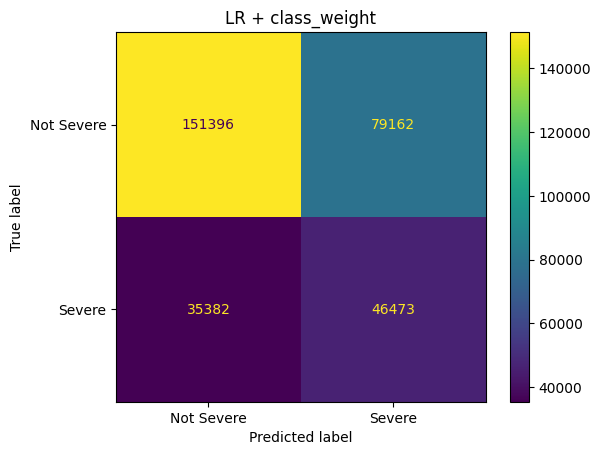


🔹 LR + SMOTE
ROC-AUC:              0.6407
PR-AUC:               0.3794
F1 (minority):        0.2561
Recall (minority):    0.1787
Precision (minority): 0.4516

Confusion Matrix:
TP: 14,628 | FN: 67,227
FP: 17,760 | TN: 212,798


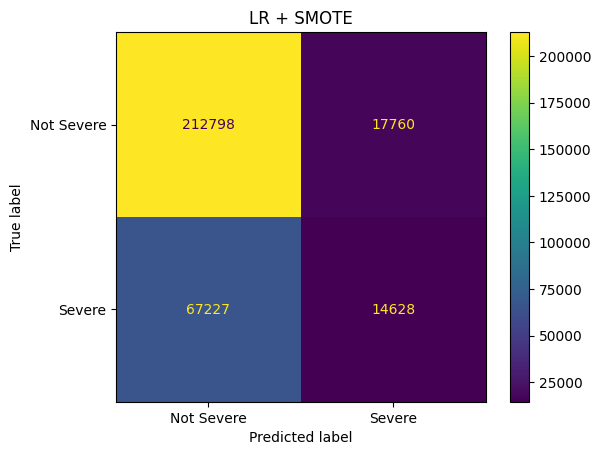


🔹 RF + class_weight
ROC-AUC:              0.5984
PR-AUC:               0.3349
F1 (minority):        0.2476
Recall (minority):    0.1840
Precision (minority): 0.3783

Confusion Matrix:
TP: 15,064 | FN: 66,791
FP: 24,756 | TN: 205,802


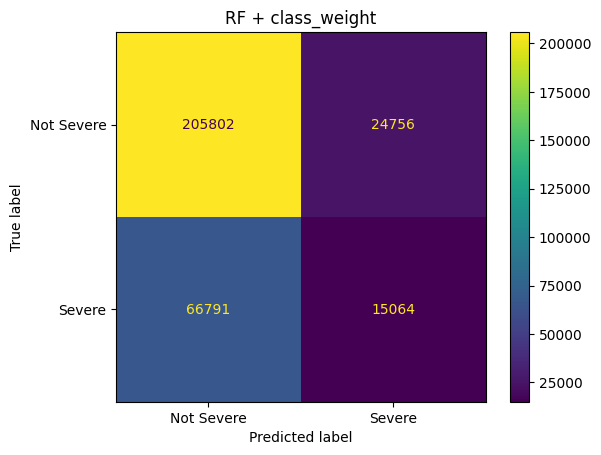


🔹 RF + SMOTE
ROC-AUC:              0.5161
PR-AUC:               0.2731
F1 (minority):        0.4147
Recall (minority):    0.9928
Precision (minority): 0.2621

Confusion Matrix:
TP: 81,269 | FN: 586
FP: 228,803 | TN: 1,755


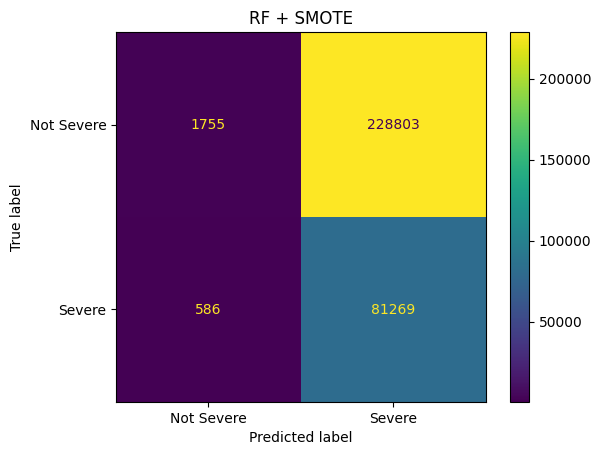


🔹 XGBoost (weighted)
ROC-AUC:              0.6602
PR-AUC:               0.4009
F1 (minority):        0.4553
Recall (minority):    0.5613
Precision (minority): 0.3830

Confusion Matrix:
TP: 45,946 | FN: 35,909
FP: 74,028 | TN: 156,530


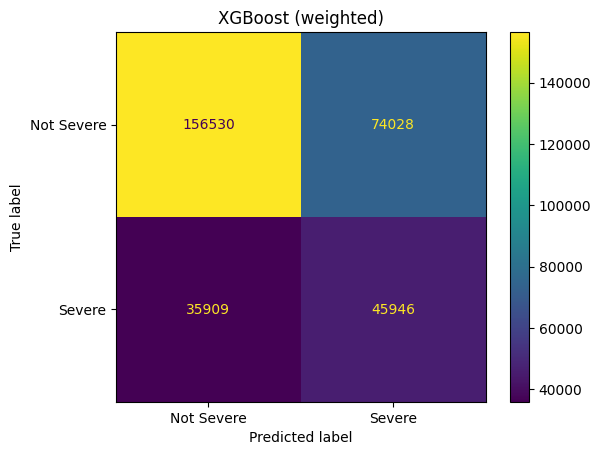

In [22]:
results = []

# Logistic Regression
results.append(evaluate_model("LR + class_weight", lr_cw, X_test_scaled, y_test))
results.append(evaluate_model("LR + SMOTE", lr_sm, X_test_scaled, y_test))

# Random Forest
results.append(evaluate_model("RF + class_weight", rf_cw, X_test, y_test))
results.append(evaluate_model("RF + SMOTE", rf_sm, X_test, y_test))

# XGBoost
results.append(evaluate_model("XGBoost (weighted)", xgb, X_test, y_test))


🔹 XGB + SMOTE
ROC-AUC:              0.5089
PR-AUC:               0.2642
F1 (minority):        0.4138
Recall (minority):    0.9811
Precision (minority): 0.2622

Confusion Matrix:
TP: 80,312 | FN: 1,543
FP: 226,022 | TN: 4,536


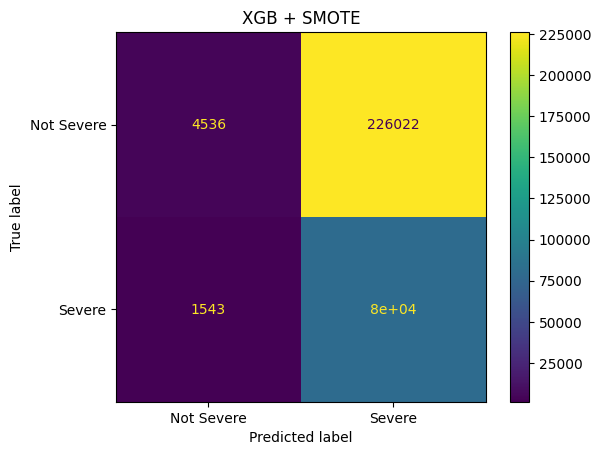

In [23]:


xgb_sm = XGBClassifier(
    n_estimators=120,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_sm.fit(X_train_sm, y_train_sm)

results.append(
    evaluate_model("XGB + SMOTE", xgb_sm, X_test, y_test)
)

In [24]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

print("\n📊 MODEL COMPARISON TABLE")
results_df.round(4)


📊 MODEL COMPARISON TABLE


,Model,ROC-AUC,PR-AUC,F1,Recall,Precision,True Positives,False Negatives,False Positives,True Negatives
4,XGBoost (weighted),0.6602,0.4009,0.4553,0.5613,0.3830,45946,35909,74028,156530
0,LR + class_weight,0.6412,0.3793,0.4480,0.5677,0.3699,46473,35382,79162,151396
1,LR + SMOTE,0.6407,0.3794,0.2561,0.1787,0.4516,14628,67227,17760,212798
2,RF + class_weight,0.5984,0.3349,0.2476,0.1840,0.3783,15064,66791,24756,205802
3,RF + SMOTE,0.5161,0.2731,0.4147,0.9928,0.2621,81269,586,228803,1755
5,XGB + SMOTE,0.5089,0.2642,0.4138,0.9811,0.2622,80312,1543,226022,4536


In [25]:
print("\n" + "="*60)
print("🏆 FINAL MODEL COMPARISON SUMMARY")
print("="*60)

for _, row in results_df.iterrows():
    print(f"\n🔹 {row['Model']}")
    print(f"  ROC-AUC: {row['ROC-AUC']:.4f}")
    print(f"  PR-AUC:  {row['PR-AUC']:.4f}")
    print(f"  Recall:  {row['Recall']:.4f}")
    print(f"  F1:      {row['F1']:.4f}")


🏆 FINAL MODEL COMPARISON SUMMARY

🔹 XGBoost (weighted)
  ROC-AUC: 0.6602
  PR-AUC:  0.4009
  Recall:  0.5613
  F1:      0.4553

🔹 LR + class_weight
  ROC-AUC: 0.6412
  PR-AUC:  0.3793
  Recall:  0.5677
  F1:      0.4480

🔹 LR + SMOTE
  ROC-AUC: 0.6407
  PR-AUC:  0.3794
  Recall:  0.1787
  F1:      0.2561

🔹 RF + class_weight
  ROC-AUC: 0.5984
  PR-AUC:  0.3349
  Recall:  0.1840
  F1:      0.2476

🔹 RF + SMOTE
  ROC-AUC: 0.5161
  PR-AUC:  0.2731
  Recall:  0.9928
  F1:      0.4147

🔹 XGB + SMOTE
  ROC-AUC: 0.5089
  PR-AUC:  0.2642
  Recall:  0.9811
  F1:      0.4138


## Hyperparameter Tuning (XGBoost using RandomizedSearchCV)

Hyperparameter tuning is performed using RandomizedSearchCV on a sampled subset of the training data to reduce computational cost while maintaining performance.

In [26]:
# Sample for tuning (to avoid memory crash)
sample_size = 200000

X_tune = X_train.sample(sample_size, random_state=42)
y_tune = y_train.loc[X_tune.index]

print("Tuning sample shape:", X_tune.shape)

Tuning sample shape: (200000, 31)


In [27]:
from xgboost import XGBClassifier

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8]
}

In [28]:
from sklearn.model_selection import RandomizedSearchCV

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",   # FAST + memory efficient
    n_jobs=-1,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,              # keep small for 5GB
    scoring="roc_auc",
    cv=3,                   # lightweight CV
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Starting RandomizedSearchCV...")

random_search.fit(X_tune, y_tune)

Starting RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 6, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [29]:
best_params = random_search.best_params_

print("\nBest Parameters Found:")
for k, v in best_params.items():
    print(f"{k}: {v}")


Best Parameters Found:
subsample: 0.8
n_estimators: 300
max_depth: 6
learning_rate: 0.01
colsample_bytree: 0.7


In [30]:
xgb_tuned = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

print("Training final tuned XGBoost...")

xgb_tuned.fit(X_train, y_train)

Training final tuned XGBoost...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)


🔹 XGB Tuned
ROC-AUC:              0.6569
PR-AUC:               0.3961
F1 (minority):        0.4521
Recall (minority):    0.5488
Precision (minority): 0.3844

Confusion Matrix:
TP: 44,925 | FN: 36,930
FP: 71,949 | TN: 158,609


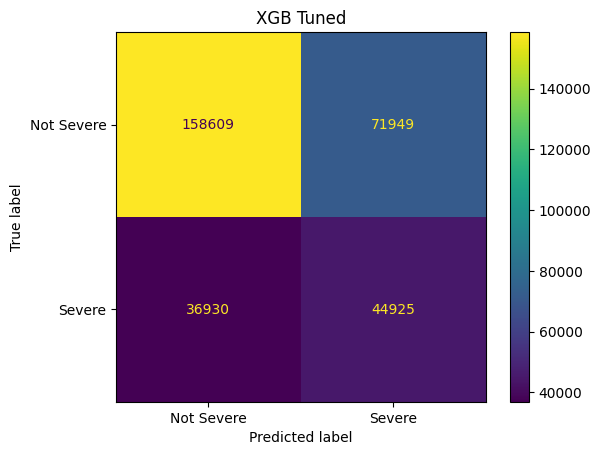

In [31]:
results.append(evaluate_model("XGB Tuned", xgb_tuned, X_test, y_test))

  XGBoost TUNED — Final Results
  ROC-AUC:              0.6569
  PR-AUC:               0.3961
  F1  (minority):       0.4521
  Recall (minority):    0.5488
  Precision (minority): 0.3844

  Confusion Matrix:
  True Positives:  44,925  | False Negatives: 36,930
  False Positives: 71,949 | True Negatives:  158,609


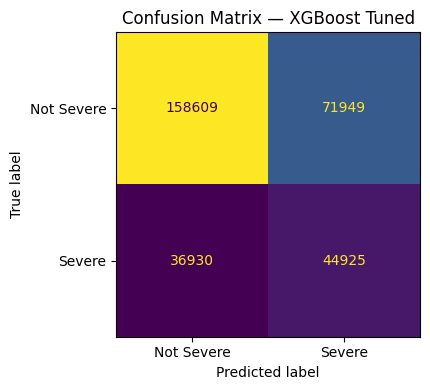

In [32]:
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, average_precision_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ── Evaluate tuned XGBoost model ──────────────────────────
y_pred = xgb_tuned.predict(X_test)              # ✅ NOT scaled
y_prob = xgb_tuned.predict_proba(X_test)[:, 1]  # ✅ NOT scaled

report = classification_report(y_test, y_pred, output_dict=True)
cm     = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"{'='*45}")
print(f"  XGBoost TUNED — Final Results")
print(f"{'='*45}")
print(f"  ROC-AUC:              {roc_auc_score(y_test, y_prob):.4f}")
print(f"  PR-AUC:               {average_precision_score(y_test, y_prob):.4f}")
print(f"  F1  (minority):       {report['1']['f1-score']:.4f}")
print(f"  Recall (minority):    {report['1']['recall']:.4f}")
print(f"  Precision (minority): {report['1']['precision']:.4f}")

print(f"\n  Confusion Matrix:")
print(f"  True Positives:  {tp:,}  | False Negatives: {fn:,}")
print(f"  False Positives: {fp:,} | True Negatives:  {tn:,}")

# ── Plot Confusion Matrix ────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Severe', 'Severe']
)

disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — XGBoost Tuned')

plt.tight_layout()
plt.show()

In [33]:
print(results_df["Model"].unique())

['XGBoost (weighted)' 'LR + class_weight' 'LR + SMOTE' 'RF + class_weight'
 'RF + SMOTE' 'XGB + SMOTE']


In [34]:
# Extract base and tuned models (FIXED)
base_row = results_df[results_df["Model"] == "XGBoost (weighted)"]
tuned_row = results_df[results_df["Model"] == "XGB + SMOTE"]

if base_row.empty or tuned_row.empty:
    print("❌ Model names not found. Check names above.")
else:
    base = base_row.iloc[0]
    tuned = tuned_row.iloc[0]

In [35]:
print(results_df.columns)

Index(['Model', 'ROC-AUC', 'PR-AUC', 'F1', 'Recall', 'Precision',
       'True Positives', 'False Negatives', 'False Positives',
       'True Negatives'],
      dtype='object')


In [36]:
# Convert AFTER all models
results_df = pd.DataFrame(results)

# Extract correct models
base = results_df[results_df["Model"] == "XGBoost (weighted)"].iloc[0]
tuned = results_df[results_df["Model"] == "XGB Tuned"].iloc[0]

comparison = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "F1", "Recall", "Precision"],
    "XGB Base": [
        base["ROC-AUC"],
        base["PR-AUC"],
        base["F1"],
        base["Recall"],
        base["Precision"]
    ],
    "XGB Tuned": [
        tuned["ROC-AUC"],
        tuned["PR-AUC"],
        tuned["F1"],
        tuned["Recall"],
        tuned["Precision"]
    ]
})

comparison["Change"] = comparison["XGB Tuned"] - comparison["XGB Base"]

comparison

,Metric,XGB Base,XGB Tuned,Change
0,ROC-AUC,0.660165,0.656919,-0.003246
1,PR-AUC,0.400850,0.396074,-0.004776
2,F1,0.455296,0.452123,-0.003173
3,Recall,0.561310,0.548836,-0.012473
4,Precision,0.382966,0.384388,0.001422


In [40]:
results_df.head(10)

,Model,ROC-AUC,PR-AUC,F1,Recall,Precision,True Positives,False Negatives,False Positives,True Negatives
0,LR + class_weight,0.641166,0.379254,0.447954,0.567748,0.369905,46473,35382,79162,151396
1,LR + SMOTE,0.640666,0.379374,0.256086,0.178706,0.451649,14628,67227,17760,212798
2,RF + class_weight,0.598421,0.334864,0.247610,0.184033,0.378302,15064,66791,24756,205802
3,RF + SMOTE,0.516134,0.273070,0.414715,0.992841,0.262097,81269,586,228803,1755
4,XGBoost (weighted),0.660165,0.400850,0.455296,0.561310,0.382966,45946,35909,74028,156530
5,XGB + SMOTE,0.508919,0.264170,0.413778,0.981150,0.262171,80312,1543,226022,4536
6,XGB Tuned,0.656919,0.396074,0.452123,0.548836,0.384388,44925,36930,71949,158609


Top 15 Important Features:


,Feature,Importance
4,year,0.445688
17,active_construction,0.121315
21,new_building,0.051977
0,BOROUGH,0.048737
30,construction_intensity,0.045000
6,hour,0.035079
5,MONTH,0.032178
26,rain_flag,0.019846
14,traffic_volume,0.018608
18,construction_change,0.015853


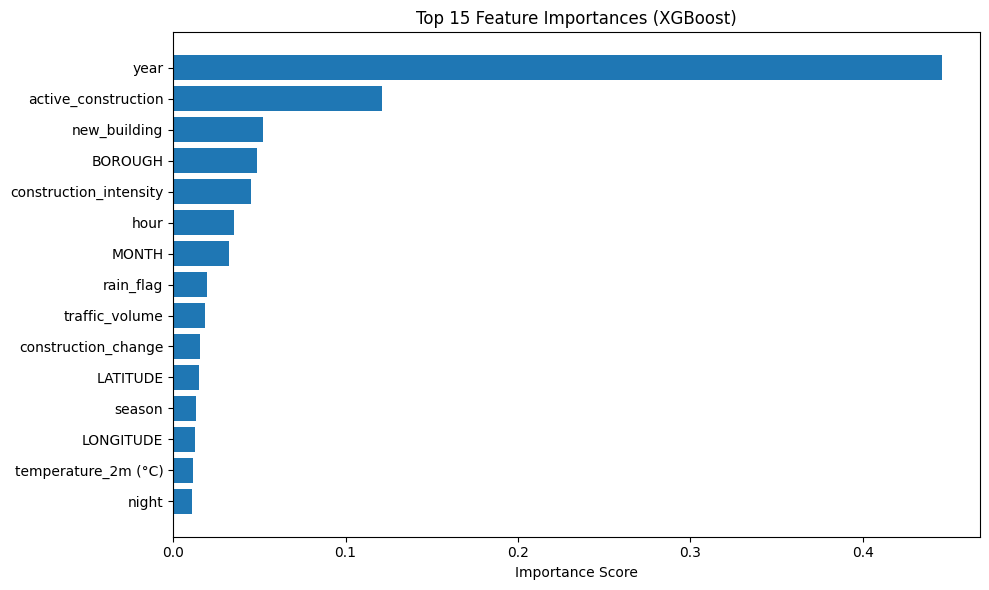

In [42]:
# Get feature importance from BEST model (XGBoost weighted)
importance = xgb.feature_importances_

# Feature names
feature_names = X_train.columns

# Create DataFrame
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort
feat_df = feat_df.sort_values(by="Importance", ascending=False)

# Top 15
top_features = feat_df.head(15)

print("Top 15 Important Features:")
display(top_features)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [45]:
print("\n" + "="*60)
print("🏆 FINAL MODEL RANKING (Best → Worst)")
print("="*60)

# Sort once
sorted_df = results_df.sort_values(by="PR-AUC", ascending=False)

# Display table
display(sorted_df)

# Print ranked list
for i, (_, row) in enumerate(sorted_df.iterrows(), start=1):
    print(f"\n#{i} 🔹 {row['Model']}")
    print("-"*35)
    print(f" ROC-AUC:   {row['ROC-AUC']:.4f}")
    print(f" PR-AUC:    {row['PR-AUC']:.4f}")
    print(f" Recall:    {row['Recall']:.4f}")
    print(f" Precision: {row['Precision']:.4f}")
    print(f" F1:        {row['F1']:.4f}")


🏆 FINAL MODEL RANKING (Best → Worst)


,Model,ROC-AUC,PR-AUC,F1,Recall,Precision,True Positives,False Negatives,False Positives,True Negatives
4,XGBoost (weighted),0.660165,0.400850,0.455296,0.561310,0.382966,45946,35909,74028,156530
6,XGB Tuned,0.656919,0.396074,0.452123,0.548836,0.384388,44925,36930,71949,158609
1,LR + SMOTE,0.640666,0.379374,0.256086,0.178706,0.451649,14628,67227,17760,212798
0,LR + class_weight,0.641166,0.379254,0.447954,0.567748,0.369905,46473,35382,79162,151396
2,RF + class_weight,0.598421,0.334864,0.247610,0.184033,0.378302,15064,66791,24756,205802
3,RF + SMOTE,0.516134,0.273070,0.414715,0.992841,0.262097,81269,586,228803,1755
5,XGB + SMOTE,0.508919,0.264170,0.413778,0.981150,0.262171,80312,1543,226022,4536



#1 🔹 XGBoost (weighted)
-----------------------------------
 ROC-AUC:   0.6602
 PR-AUC:    0.4009
 Recall:    0.5613
 Precision: 0.3830
 F1:        0.4553

#2 🔹 XGB Tuned
-----------------------------------
 ROC-AUC:   0.6569
 PR-AUC:    0.3961
 Recall:    0.5488
 Precision: 0.3844
 F1:        0.4521

#3 🔹 LR + SMOTE
-----------------------------------
 ROC-AUC:   0.6407
 PR-AUC:    0.3794
 Recall:    0.1787
 Precision: 0.4516
 F1:        0.2561

#4 🔹 LR + class_weight
-----------------------------------
 ROC-AUC:   0.6412
 PR-AUC:    0.3793
 Recall:    0.5677
 Precision: 0.3699
 F1:        0.4480

#5 🔹 RF + class_weight
-----------------------------------
 ROC-AUC:   0.5984
 PR-AUC:    0.3349
 Recall:    0.1840
 Precision: 0.3783
 F1:        0.2476

#6 🔹 RF + SMOTE
-----------------------------------
 ROC-AUC:   0.5161
 PR-AUC:    0.2731
 Recall:    0.9928
 Precision: 0.2621
 F1:        0.4147

#7 🔹 XGB + SMOTE
-----------------------------------
 ROC-AUC:   0.5089
 PR-AUC:    0.2642